# Physics-Informed Neural Network for a 1D Poisson Equation

This notebook extends the basic 1D PINN example to a problem with a non-zero source term.

The governing equation is

\[
\frac{d^2T}{dx^2}+\pi^2\sin(\pi x)=0,
\qquad 0\leq x\leq1
\]

with boundary conditions

\[
T(0)=0,
\qquad
T(1)=0.
\]

The analytical solution is

\[
T(x)=\sin(\pi x).
\]

The PINN is trained by minimizing the PDE residual together with the boundary-condition errors.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(43)

pi = torch.pi

# Collocation points in the domain 0 <= x <= 1
x_colloc = torch.linspace(0, 1, 100).view(-1, 1)

# Required because derivatives with respect to x will be calculated
x_colloc.requires_grad_(True)

# Neural network: x -> T(x)
model = nn.Sequential(
    nn.Linear(1, 32),
    nn.Tanh(),
    nn.Linear(32,32),
    nn.Tanh(),
    nn.Linear(32,1)
)

# Boundary locations
x_left  = torch.tensor([[0.0]])
x_right = torch.tensor([[1.0]])

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

# Reduce learning rate during training
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=1000,
    gamma=0.5
)

## PINN Training

At each epoch, the neural network predicts \(T(x)\). PyTorch automatic differentiation is used to calculate

\[
\frac{dT}{dx}
\]

and

\[
\frac{d^2T}{dx^2}.
\]

The PDE residual is

\[
r(x) = \frac{d^2T}{dx^2} + \pi^2\sin(\pi x).
\]

Training minimizes the mean-squared PDE residual together with the two boundary-condition errors.

In [2]:
n_epochs = 3000

for epoch in range(n_epochs):
    # Forward pass: predict T(x)
    T = model(x_colloc)

    # Automatic differentiation
    dT_dx = torch.autograd.grad(
        T, x_colloc,
        grad_outputs = torch.ones_like(T),
        create_graph=True
    )[0]

    d2T_dx2 = torch.autograd.grad(
        dT_dx, x_colloc,
        grad_outputs = torch.ones_like(dT_dx),
        create_graph=True
    )[0]

    # PDE loss: d²T/dx² + pi² sin(pi x) = 0
    pde_residual = d2T_dx2 + ((pi)**2)*(torch.sin(pi*x_colloc))
    loss_pde = torch.mean(pde_residual**2)

    # Boundary-condition loss: T(0) = 0; T(1) = 0
    T_left  = model(x_left)
    T_right = model(x_right)

    loss_left   = torch.mean((T_left-0.0)**2)
    loss_right  = torch.mean((T_right-0.0)**2)

    loss_bc = loss_left + loss_right

    loss = loss_bc + loss_pde

    # Update NN parameters
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    # Display training progress
    if epoch % 300 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"PDE loss = {loss_pde.item():.6f} | "
            f"BC loss = {loss_bc.item():.6f} | "
            f"Total loss = {loss.item():.6f}"
        )

Epoch    0 | PDE loss = 47.944595 | BC loss = 0.144468 | Total loss = 48.089066
Epoch  300 | PDE loss = 0.002511 | BC loss = 0.000003 | Total loss = 0.002514
Epoch  600 | PDE loss = 0.000194 | BC loss = 0.000000 | Total loss = 0.000194
Epoch  900 | PDE loss = 0.000963 | BC loss = 0.000042 | Total loss = 0.001005
Epoch 1200 | PDE loss = 0.000084 | BC loss = 0.000000 | Total loss = 0.000084
Epoch 1500 | PDE loss = 0.000074 | BC loss = 0.000000 | Total loss = 0.000074
Epoch 1800 | PDE loss = 0.000064 | BC loss = 0.000000 | Total loss = 0.000064
Epoch 2100 | PDE loss = 0.000055 | BC loss = 0.000000 | Total loss = 0.000055
Epoch 2400 | PDE loss = 0.000050 | BC loss = 0.000000 | Total loss = 0.000050
Epoch 2700 | PDE loss = 0.000045 | BC loss = 0.000000 | Total loss = 0.000045


## Evaluation

The trained PINN is evaluated at selected points and compared with the analytical solution

\[
T(x)=\sin(\pi x).
\]

In [3]:
x_check = torch.linspace(0,1,5).view(-1,1)

model.eval()
with torch.no_grad():
    T_pred = model(x_check)

print("\nPINN vs analytical solution\n")
for i in range(len(x_check)):
    x_val       = x_check[i].item()
    pinn_val    = T_pred[i].item()
    exact_val   = torch.sin(pi * x_check[i]).item()

    print(
        f"x     = {x_val:.2f} | "
        f"PINN  = {pinn_val:.4f} | "
        f"Exact = {exact_val:.4f}"
    )


PINN vs analytical solution

x     = 0.00 | PINN  = 0.0000 | Exact = 0.0000
x     = 0.25 | PINN  = 0.7071 | Exact = 0.7071
x     = 0.50 | PINN  = 1.0000 | Exact = 1.0000
x     = 0.75 | PINN  = 0.7071 | Exact = 0.7071
x     = 1.00 | PINN  = -0.0000 | Exact = -0.0000


## Solution Comparison

The PINN prediction is compared with the analytical solution across the full spatial domain.

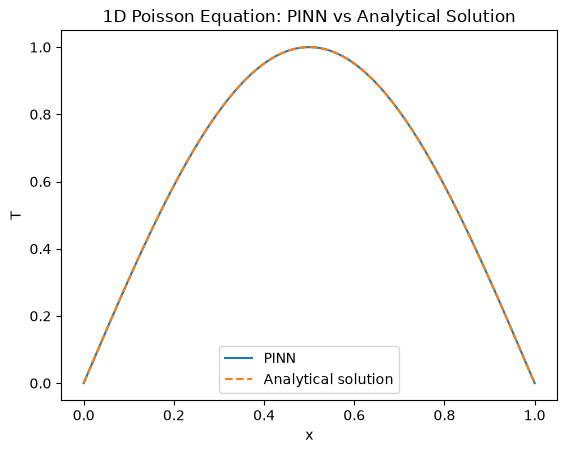

In [4]:
x_plot = torch.linspace(0, 1, 100).view(-1, 1)
with torch.no_grad():
    T_pinn = model(x_plot)


T_exact = torch.sin(pi*x_plot)

plt.plot(
    x_plot.numpy(),
    T_pinn.numpy(),
    label="PINN"
)

plt.plot(
    x_plot.numpy(),
    T_exact.numpy(),
    "--",
    label="Analytical solution"
)

plt.title("1D Poisson Equation: PINN vs Analytical Solution")
plt.xlabel("x")
plt.ylabel("T")
plt.legend()
plt.show()